In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
titanic_df = pd.read_csv('survival.csv')

In [3]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Data Exploration
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Identifying any nulls 
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Preview of dataset
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# Data exploration
titanic_df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [9]:
# Data exploration
titanic_df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [10]:
corr_columns = titanic_df[['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']]
corr_matrix = corr_columns.corr(numeric_only=True)
corr_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


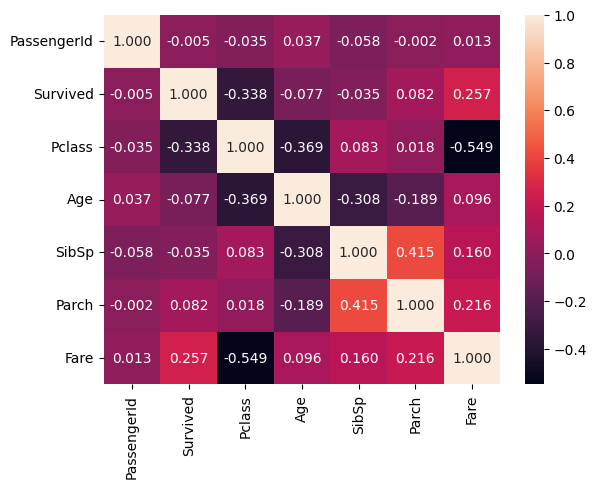

In [11]:
sns.heatmap(corr_matrix, annot=True, fmt=".3f")
plt.show()

In [12]:
#Data Preprocessing

In [13]:
# Dropping Cabin (too many nulls)
titanic_df_copy = titanic_df.copy()
titanic_df_copy = titanic_df_copy.drop(columns=['Cabin'])
titanic_df_copy

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [14]:
# Fill missing age with median
titanic_df_copy["Age"] = titanic_df_copy["Age"].fillna(titanic_df_copy["Age"].median())

In [15]:
# Fill missing Embark with mode
titanic_df_copy["Embarked"] = titanic_df_copy["Embarked"].fillna(titanic_df_copy["Embarked"].mode()[0])

In [16]:
# Checking for any more nulls
titanic_df_copy.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [17]:
# Dropping columns name, passengerID, ticket 
titanic_df_copy = titanic_df_copy.drop(columns=['Name',"PassengerId","Ticket"])

In [18]:
titanic_df_copy.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [19]:
# Encoding categorical variables
# One hot encoding for gender and embarked columns but dropping one column after to reduce multicollinearity
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output = False, drop='first').set_output(transform='pandas')
encoder_transform = encoder.fit_transform(titanic_df_copy[['Sex','Embarked']])
titanic_df_copy = titanic_df_copy.drop(columns=['Sex','Embarked']).join(encoder_transform)

In [20]:
# Ordinal encode PClass because from data exploration found that higher class had higher survival percentage.
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[[1,2,3]])
enc_transform = enc.fit_transform(titanic_df_copy[['Pclass']])
enc_df = pd.DataFrame(enc_transform, columns=['Pclass'], index=titanic_df_copy.index)
titanic_df_copy = titanic_df_copy.drop(columns=['Pclass']).join(enc_df)

In [21]:
titanic_df_copy.head()

,Survived,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass
0,0,22.0,1,0,7.2500,1.0,0.0,1.0,2.0
1,1,38.0,1,0,71.2833,0.0,0.0,0.0,0.0
2,1,26.0,0,0,7.9250,0.0,0.0,1.0,2.0
3,1,35.0,1,0,53.1000,0.0,0.0,1.0,0.0
4,0,35.0,0,0,8.0500,1.0,0.0,1.0,2.0


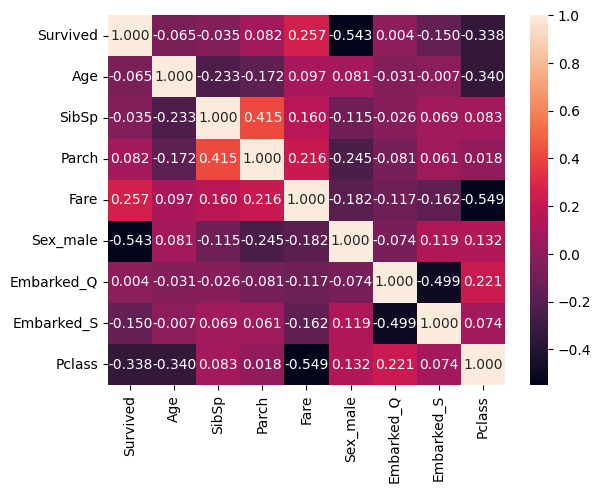

In [22]:
# Show updated heat map
matrix = titanic_df_copy.corr(numeric_only=True)
sns.heatmap(matrix, annot=True, fmt=".3f")
plt.show()

In [23]:
# Split X and y
X = titanic_df_copy.drop(columns=['Survived'])
y = titanic_df_copy['Survived']

In [24]:
# Split data into training, validation, and testing sets (70,15,15)
from sklearn.model_selection import train_test_split 

# Test set 15%
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Split the remaining 85% into Train (70% total) and Val (15% total)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.176, random_state=42)

In [25]:
# Scaling units using min-max only for units that were not one hot encoded
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_columns = ["Age", "Fare", "SibSp", "Parch","Pclass"]

X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_val[numeric_columns] = scaler.transform(X_val[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

In [26]:
# KNN MODEL
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Define model and neighbors
knn_model = KNeighborsClassifier()
param_grid_knn = {'n_neighbors': [3,5,7,10,15]}
knn_grid_search = GridSearchCV(estimator=knn_model, param_grid=param_grid_knn, cv=5,  scoring='f1')

# Training KNN/ showing f1 score at different k
knn_grid_search.fit(X_train, y_train)
for i, k in enumerate(param_grid_knn['n_neighbors']):
    score = knn_grid_search.cv_results_['mean_test_score'][i]
    print(f"K = {k}; CV F1 score:{score: .4f}")

# Selecting best k model
best_knn_model = knn_grid_search.best_estimator_
print(f"\nBest K Value found: {knn_grid_search.best_params_}\n")
best_knn_model.fit(X_train, y_train)

# Predict test set and report f1 score
y_knn_predict = best_knn_model.predict(X_test)
knn_f1_score = f1_score(y_test, y_knn_predict)
print(f"F1 score for KNN: {knn_f1_score:.4f}")
print(confusion_matrix(y_test, y_knn_predict))
print(classification_report(y_test, y_knn_predict))

K = 3; CV F1 score: 0.7033
K = 5; CV F1 score: 0.6937
K = 7; CV F1 score: 0.6744
K = 10; CV F1 score: 0.6864
K = 15; CV F1 score: 0.6774

Best K Value found: {'n_neighbors': 3}

F1 score for KNN: 0.7273
[[64 14]
 [16 40]]
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        78
           1       0.74      0.71      0.73        56

    accuracy                           0.78       134
   macro avg       0.77      0.77      0.77       134
weighted avg       0.78      0.78      0.78       134



In [27]:
# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
dtc_model = DecisionTreeClassifier(random_state=42)
param_grid = {'max_depth':[2,3,4,5,6]}

dt_grid_search = GridSearchCV(estimator=dtc_model, param_grid=param_grid, cv=5, scoring='f1')
dt_grid_search.fit(X_train, y_train)

# Reporting f1 score for each depth
for i, depth in enumerate(param_grid['max_depth']):
    score = dt_grid_search.cv_results_['mean_test_score'][i]
    print(f"Max Depth {depth}: F1 Score: {score:.4f}")

# Selecting Best Model and re training
best_tree = dt_grid_search.best_estimator_
print(f"\nBest Model: {dt_grid_search.best_params_}\n")
best_tree.fit(X_train, y_train)

# Predicting and reporting f1 score
y_predict_dt = best_tree.predict(X_test)
dt_f1 = f1_score(y_test, y_predict_dt)
print(f"F1 Score of Decision Tree: {dt_f1:.3f}\n")
print(confusion_matrix(y_test, y_predict_dt))
print(classification_report(y_test, y_predict_dt))

Max Depth 2: F1 Score: 0.6644
Max Depth 3: F1 Score: 0.7255
Max Depth 4: F1 Score: 0.7044
Max Depth 5: F1 Score: 0.7162
Max Depth 6: F1 Score: 0.7198

Best Model: {'max_depth': 3}

F1 Score of Decision Tree: 0.785

[[69  9]
 [14 42]]
              precision    recall  f1-score   support

           0       0.83      0.88      0.86        78
           1       0.82      0.75      0.79        56

    accuracy                           0.83       134
   macro avg       0.83      0.82      0.82       134
weighted avg       0.83      0.83      0.83       134



In [28]:
# Linear Regression
from sklearn.linear_model import LinearRegression

linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

# use threshold of 0.5 to convert to binary for classification
y_predict_lr = (linear_reg_model.predict(X_test) > 0.5).astype(int)

# reporting f1 score
print(f"F1 Score of Linear Regression: {f1_score(y_test, y_predict_lr):.3f}\n")
print(confusion_matrix(y_test, y_predict_lr),"\n")
print(classification_report(y_test, y_predict_lr))

F1 Score of Linear Regression: 0.748

[[67 11]
 [16 40]] 

              precision    recall  f1-score   support

           0       0.81      0.86      0.83        78
           1       0.78      0.71      0.75        56

    accuracy                           0.80       134
   macro avg       0.80      0.79      0.79       134
weighted avg       0.80      0.80      0.80       134



In [29]:
# Naive Bayes Model
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import ComplementNB

# Training Model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Find threshold on validation set only
y_val_prob = nb_model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)

# Getting threshold
f1_score_nb = 2 * (precision * recall) / (precision + recall)
best_idx_nb = np.argmax(f1_score_nb)
best_threshold_nb = thresholds[best_idx_nb]
print(f"Best threshold found: {best_threshold_nb:.3f}")

# Predictions using threshold
y_prob_test = nb_model.predict_proba(X_test)[:, 1]
y_pred_nb_final = (y_prob_test >= best_threshold_nb).astype(int)

# reports
nb_test_f1 = f1_score(y_test, y_pred_nb_final)
print(f"F1 Score of Naive Bayes Model: {nb_test_f1:.3f}\n")
print(confusion_matrix(y_test, y_pred_nb_final))
print(classification_report(y_test, y_pred_nb_final))

Best threshold found: 0.462
F1 Score of Naive Bayes Model: 0.724

[[60 18]
 [14 42]]
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        78
           1       0.70      0.75      0.72        56

    accuracy                           0.76       134
   macro avg       0.76      0.76      0.76       134
weighted avg       0.76      0.76      0.76       134



In [30]:
# Logistic regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=500)

#values of C to test in model
log_param_grid = {"C": [0.01, 0.1, 1, 10]}
grid_log = GridSearchCV(LogisticRegression(max_iter=500), param_grid=log_param_grid,cv=5, scoring='f1')
grid_log.fit(X_train, y_train)

#print results accuracy of each C
for i, C_val in enumerate(log_param_grid["C"]):
    score = grid_log.cv_results_["mean_test_score"][i]
    print(f"C = {C_val}: CV F1 Score = {score:.3f}")

#Getting best Model
print("\nBest C:", grid_log.best_params_, "\n")
best_log = grid_log.best_estimator_

best_log.fit(X_train, y_train)

#finding threshold based on validation set
y_val_probs = best_log.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_val_probs)
f1_score_log = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx_log = np.argmax(f1_score_log)
best_threshold_log = thresholds[best_idx_log]
print(f"Best threshold from Validation: {best_threshold_log:.3f}\n")

y_test_probs = best_log.predict_proba(X_test)[:, 1]
y_test_preds = (y_test_probs >= best_threshold_log).astype(int)

#reports
print(f"Logistic Regression F1 Score:, {f1_score(y_test, y_test_preds):.4f}")
print("\n",confusion_matrix(y_test, y_test_preds))
print(classification_report(y_test, y_test_preds))

C = 0.01: CV F1 Score = 0.197
C = 0.1: CV F1 Score = 0.701
C = 1: CV F1 Score = 0.704
C = 10: CV F1 Score = 0.712

Best C: {'C': 10} 

Best threshold from Validation: 0.588

Logistic Regression F1 Score:, 0.7500

 [[69  9]
 [17 39]]
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        78
           1       0.81      0.70      0.75        56

    accuracy                           0.81       134
   macro avg       0.81      0.79      0.80       134
weighted avg       0.81      0.81      0.80       134



In [31]:
#SVM
from sklearn.svm import SVC
svm_param_grid = {"C": [0.01, 0.1, 1, 10],"kernel": ["linear", "rbf"]}
#gridsearch SVM
grid_svm = GridSearchCV(SVC(probability=True), param_grid=svm_param_grid, cv=5, scoring='f1')
grid_svm.fit(X_train, y_train)

#print report for each C
for i in range(len(grid_svm.cv_results_["params"])):
    params = grid_svm.cv_results_["params"][i]
    score = grid_svm.cv_results_["mean_test_score"][i]
    print(f"{params}: CV F1 Score = {score:.3f}")

#best SVM model
print("\nBest Parameters:", grid_svm.best_params_, "\n")
best_svm = grid_svm.best_estimator_

#finding threshold based on validation set
y_val_prob_svm = best_svm.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob_svm)
f1_score_svm = 2 * (precision * recall) / (precision + recall+1e-8)
best_idx_svm = np.argmax(f1_score_svm)
best_threshold_svm = thresholds[best_idx_svm]
print(f"Best threshold SVM: {best_threshold_svm:.3f}\n")

y_test_probs_svm = best_svm.predict_proba(X_test)[:, 1]
y_test_preds_svm = (y_test_probs_svm >= best_threshold_svm).astype(int)

#reports
print(f"SVM F1 Score: {f1_score(y_test, y_test_preds_svm):.4f}")
print("\n", confusion_matrix(y_test, y_test_preds_svm))
print(classification_report(y_test, y_test_preds_svm))

{'C': 0.01, 'kernel': 'linear'}: CV F1 Score = 0.365
{'C': 0.01, 'kernel': 'rbf'}: CV F1 Score = 0.000
{'C': 0.1, 'kernel': 'linear'}: CV F1 Score = 0.705
{'C': 0.1, 'kernel': 'rbf'}: CV F1 Score = 0.710
{'C': 1, 'kernel': 'linear'}: CV F1 Score = 0.705
{'C': 1, 'kernel': 'rbf'}: CV F1 Score = 0.686
{'C': 10, 'kernel': 'linear'}: CV F1 Score = 0.705
{'C': 10, 'kernel': 'rbf'}: CV F1 Score = 0.694

Best Parameters: {'C': 0.1, 'kernel': 'rbf'} 

Best threshold SVM: 0.176

SVM F1 Score: 0.7302

 [[54 24]
 [10 46]]
              precision    recall  f1-score   support

           0       0.84      0.69      0.76        78
           1       0.66      0.82      0.73        56

    accuracy                           0.75       134
   macro avg       0.75      0.76      0.75       134
weighted avg       0.77      0.75      0.75       134



In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score

models = {
    "KNN":                 (y_test, y_knn_predict),
    "Decision Tree":       (y_test, y_predict_dt),
    "Linear Regression":   (y_test, y_predict_lr),
    "Naive Bayes":         (y_test, y_pred_nb_final),
    "Logistic Regression": (y_test, y_test_preds),
    "SVM":                 (y_test, y_test_preds_svm),
}

print(f"{'Model':<22} {'Accuracy':>9} {'F1(1)':>9} {'Recall(1)':>10}  Confusion Matrix")
print("-" * 75)

for name, (y_true, y_pred) in models.items():
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    print(f"{name:<22} {acc:>9.3f} {f1:>9.3f} {rec:>10.3f}  TN={tn} FP={fp} FN={fn} TP={tp}")

Model                   Accuracy     F1(1)  Recall(1)  Confusion Matrix
---------------------------------------------------------------------------
KNN                        0.776     0.727      0.714  TN=64 FP=14 FN=16 TP=40
Decision Tree              0.828     0.785      0.750  TN=69 FP=9 FN=14 TP=42
Linear Regression          0.799     0.748      0.714  TN=67 FP=11 FN=16 TP=40
Naive Bayes                0.761     0.724      0.750  TN=60 FP=18 FN=14 TP=42
Logistic Regression        0.806     0.750      0.696  TN=69 FP=9 FN=17 TP=39
SVM                        0.746     0.730      0.821  TN=54 FP=24 FN=10 TP=46
